<a href="https://colab.research.google.com/github/Omar-Qaid/CNNs/blob/main/CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Convolutional Neural Networks (CNNs)

**Convolutional Neural Networks (CNNs)** are a class of deep learning models primarily used for analyzing visual imagery. They are particularly effective for tasks like image classification, object detection, and image segmentation.

**Key Components of a CNN:**

1.  **Convolutional Layer:** This is the core building block. It applies a set of learnable filters (kernels) to the input image, performing a convolution operation. Each filter detects specific features like edges, textures, or patterns.

2.  **Activation Function (e.g., ReLU):** Applied after the convolutional layer, it introduces non-linearity into the model, allowing it to learn more complex patterns.

3.  **Pooling Layer (e.g., Max Pooling):** Reduces the spatial dimensions of the feature maps, which helps to decrease computational cost, control overfitting, and make the model more robust to variations in position of features.

4.  **Fully Connected Layer:** After several convolutional and pooling layers, the high-level features extracted by these layers are flattened and fed into one or more fully connected (dense) layers, similar to a traditional neural network. These layers are responsible for classification based on the learned features.

5.  **Output Layer:** The final fully connected layer with an activation function (e.g., softmax for multi-class classification) that produces the final prediction.

**How they work (Simplified):**

Imagine you're trying to teach a computer to recognize a cat. A traditional neural network might struggle because a cat's image can vary greatly in pixel values based on lighting, angle, and position. A CNN, however, uses its filters to detect specific features (like whiskers, ears, or eyes) regardless of where they appear in the image. These detected features are then combined by deeper layers to form more complex patterns, eventually leading to the recognition of a "cat."

### Example: Simple CNN for Image Classification (MNIST Dataset)

This example demonstrates a basic CNN to classify handwritten digits from the MNIST dataset. The MNIST dataset consists of 60,000 training images and 10,000 testing images of handwritten digits (0-9).

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Load and preprocess the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Reshape images to add a channel dimension (required for CNNs)
# MNIST images are 28x28 grayscale, so reshape to (28, 28, 1)
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

# Convert labels to one-hot encoding (e.g., 5 -> [0,0,0,0,0,1,0,0,0,0])
train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

print(f"Train images shape: {train_images.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Test labels shape: {test_labels.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images shape: (60000, 28, 28, 1)
Test images shape: (10000, 28, 28, 1)
Train labels shape: (60000, 10)
Test labels shape: (10000, 10)


In [2]:
# 2. Define the CNN model architecture
model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    # Pooling Layer 1
    layers.MaxPooling2D((2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    # Pooling Layer 2
    layers.MaxPooling2D((2, 2)),

    # Convolutional Layer 3
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten the output for the Fully Connected Layer
    layers.Flatten(),
    # Fully Connected Layer
    layers.Dense(64, activation='relu'),
    # Output Layer (10 classes for digits 0-9)
    layers.Dense(10, activation='softmax')
])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# 3. Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the model
history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))

# 5. Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nTest accuracy: {test_acc}")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 28ms/step - accuracy: 0.8934 - loss: 0.3332 - val_accuracy: 0.9872 - val_loss: 0.0395
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9853 - loss: 0.0468 - val_accuracy: 0.9878 - val_loss: 0.0376
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 27ms/step - accuracy: 0.9901 - loss: 0.0312 - val_accuracy: 0.9902 - val_loss: 0.0317
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 27ms/step - accuracy: 0.9921 - loss: 0.0239 - val_accuracy: 0.9915 - val_loss: 0.0273
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9946 - loss: 0.0182 - val_accuracy: 0.9907 - val_loss: 0.0318
313/313 - 2s - 7ms/step - accuracy: 0.9907 - loss: 0.0318

Test accuracy: 0.9907000064849854


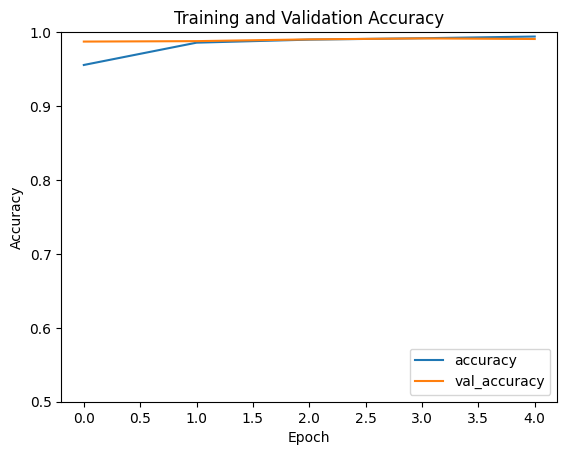

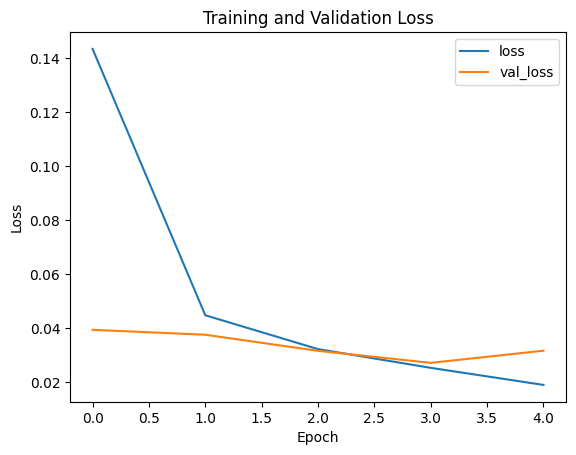

In [4]:
# 6. Visualize training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()